In [1]:
import sys
from pathlib import Path
sys.path.append("..")
from src.enrichment import compute_bes, permutation_null, run_ora

import numpy as np
import pandas as pd

import re

import gseapy as gp

# Expanding STAT3

In [61]:
background = pd.read_csv("../data/enrich_example/background.csv")
genelist_10 = pd.read_csv("../data/enrich_example/genelist_10.csv")
genelist_20 = pd.read_csv("../data/enrich_example/genelist_20.csv")
genelist_40 = pd.read_csv("../data/enrich_example/genelist_40.csv")

In [62]:
background = background.values.reshape(-1).tolist()
genelist_10 = genelist_10.values.reshape(-1).tolist()
genelist_20 = genelist_20.values.reshape(-1).tolist()
genelist_40 = genelist_40.values.reshape(-1).tolist()

In [63]:
library = "Reactome_Pathways_2024"
if library in gp.get_library_name(organism="Human"):
    print(f"{library} are available in gseapy.")

Reactome_Pathways_2024 are available in gseapy.


In [64]:
term_df_10 = run_ora(genelist_10, background, library)
term_df_20 = run_ora(genelist_20, background, library)
term_df_40 = run_ora(genelist_40, background, library)

In [67]:
term_df_10.head()

,library,term,q_value,p_value,genes,overlap_size,term_size
0,Reactome_Pathways_2024,Cytokine Signaling in Immune System,0.000014,1.830909e-07,STAT5A;STAT5B;UBA7;NLRC5;GBP2;GBP1,6,6
1,Reactome_Pathways_2024,Immune System,0.000069,2.514265e-06,STAT5A;STAT5B;UBA7;MVP;NLRC5;GBP2;GBP1,7,7
2,Reactome_Pathways_2024,Erythropoietin Activates STAT5,0.000069,3.559229e-06,STAT5A;STAT5B,2,2
3,Reactome_Pathways_2024,STAT5 Activation,0.000069,3.559229e-06,STAT5A;STAT5B,2,2
4,Reactome_Pathways_2024,Interleukin-9 Signaling,0.000085,6.098809e-06,STAT5A;STAT5B,2,2


In [68]:
term_df_20.head()

,library,term,q_value,p_value,genes,overlap_size,term_size
0,Reactome_Pathways_2024,Cytokine Signaling in Immune System,0.000001,7.648983e-09,STAT5A;STAT5B;UBA7;IRF1;CASP1;NLRC5;GBP2;GBP1;...,9,9
1,Reactome_Pathways_2024,Immune System,0.000001,1.891174e-08,STAT5A;STAT5B;UBA7;IRF1;MVP;DHX58;CASP1;NLRC5;...,12,12
2,Reactome_Pathways_2024,Interferon Gamma Signaling,0.000079,1.627009e-06,IRF1;GBP2;GBP1;IRF9,4,4
3,Reactome_Pathways_2024,Interferon Signaling,0.000130,3.596587e-06,UBA7;IRF1;GBP2;GBP1;IRF9,5,5
4,Reactome_Pathways_2024,Erythropoietin Activates STAT5,0.000408,1.687929e-05,STAT5A;STAT5B,2,2


In [69]:
term_df_40.head()

,library,term,q_value,p_value,genes,overlap_size,term_size
0,Reactome_Pathways_2024,Immune System,2.552564e-13,1.215507e-15,STAT5A;STAT5B;BTN3A1;DTX3L;RIPK3;UBA7;MVP;STAT...,24,24
1,Reactome_Pathways_2024,Cytokine Signaling in Immune System,1.903873e-10,1.813212e-12,STAT5A;STAT5B;UBA7;STAT2;NLRC5;PSMB8;SOCS3;IRF...,15,15
2,Reactome_Pathways_2024,Interferon Signaling,2.821036e-09,4.030051e-11,SOCS3;UBA7;IRF1;STAT2;IRF2;GBP2;B2M;GBP1;IRF9;...,10,10
3,Reactome_Pathways_2024,Interferon Alpha Beta Signaling,4.238615e-09,8.073552e-11,SOCS3;IRF1;STAT2;IRF2;GBP2;IRF9;PSMB8,7,7
4,Reactome_Pathways_2024,Interferon Gamma Signaling,1.800609e-08,4.287165e-10,SOCS3;IRF1;IRF2;GBP2;B2M;GBP1;IRF9,7,7


In [70]:
bes_info_10 = compute_bes(
            term_df=term_df_10,
            gene_list=genelist_10,
            c=10,
            tau=0.5,
            q_threshold=0.05,
        )

bes_info_20 = compute_bes(
            term_df=term_df_20,
            gene_list=genelist_20,
            c=10,
            tau=0.5,
            q_threshold=0.05,
        )

bes_info_40 = compute_bes(
            term_df=term_df_40,
            gene_list=genelist_40,
            c=10,
            tau=0.5,
            q_threshold=0.05,
        )

In [71]:
bes_info_10["bes_raw"], bes_info_20["bes_raw"], bes_info_40["bes_raw"]

(153.52098770448708, 163.39203465774375, 254.34183261489326)

In [89]:
def _log_progress(done: int, total: int) -> None:
    if done == total or done % 50 == 0:
        print(f"Permutation null progress: {done}/{total} ({100.0 * done / total:.0f}%)")

In [90]:
null_values_10 = permutation_null(
                    background=background,
                    gene_list_size=len(genelist_10),
                    library=library,
                    b_perm=300,
                    c=10,
                    tau=0.5,
                    q_threshold=0.05,
                    seed=42,
                    progress_callback=_log_progress,
                )

Permutation null progress: 50/300 (17%)
Permutation null progress: 100/300 (33%)
Permutation null progress: 150/300 (50%)
Permutation null progress: 200/300 (67%)
Permutation null progress: 250/300 (83%)
Permutation null progress: 300/300 (100%)


In [91]:
null_values_20 = permutation_null(
                    background=background,
                    gene_list_size=len(genelist_20),
                    library=library,
                    b_perm=300,
                    c=10,
                    tau=0.5,
                    q_threshold=0.05,
                    seed=42,
                    progress_callback=_log_progress,
                )

Permutation null progress: 50/300 (17%)
Permutation null progress: 100/300 (33%)
Permutation null progress: 150/300 (50%)
Permutation null progress: 200/300 (67%)
Permutation null progress: 250/300 (83%)
Permutation null progress: 300/300 (100%)


In [92]:
null_values_40 = permutation_null(
                    background=background,
                    gene_list_size=len(genelist_40),
                    library=library,
                    b_perm=300,
                    c=10,
                    tau=0.5,
                    q_threshold=0.05,
                    seed=42,
                    progress_callback=_log_progress,
                )

Permutation null progress: 50/300 (17%)
Permutation null progress: 100/300 (33%)
Permutation null progress: 150/300 (50%)
Permutation null progress: 200/300 (67%)
Permutation null progress: 250/300 (83%)
Permutation null progress: 300/300 (100%)


In [93]:
def _null_stats(bes_raw: float, null_values: np.ndarray) -> tuple[float, float, int]:
    valid = null_values[np.isfinite(null_values)]
    if valid.size == 0:
        return float("nan"), float("nan"), 0

    mean = float(valid.mean())
    std = float(valid.std(ddof=0))
    bes_z = float((bes_raw - mean) / std) if std > 0 else float("nan")
    bes_p_emp = float((np.sum(valid >= bes_raw) + 1) / (len(valid) + 1))
    return bes_z, bes_p_emp, int(len(valid))

In [94]:
bes_raw_10 = bes_info_10["bes_raw"]
bes_z_10, bes_p_emp_10, null_count_10 = _null_stats(bes_raw_10, null_values_10)

bes_raw_20 = bes_info_20["bes_raw"]
bes_z_20, bes_p_emp_20, null_count_20 = _null_stats(bes_raw_20, null_values_20)

bes_raw_40 = bes_info_40["bes_raw"]
bes_z_40, bes_p_emp_40, null_count_40 = _null_stats(bes_raw_40, null_values_40)

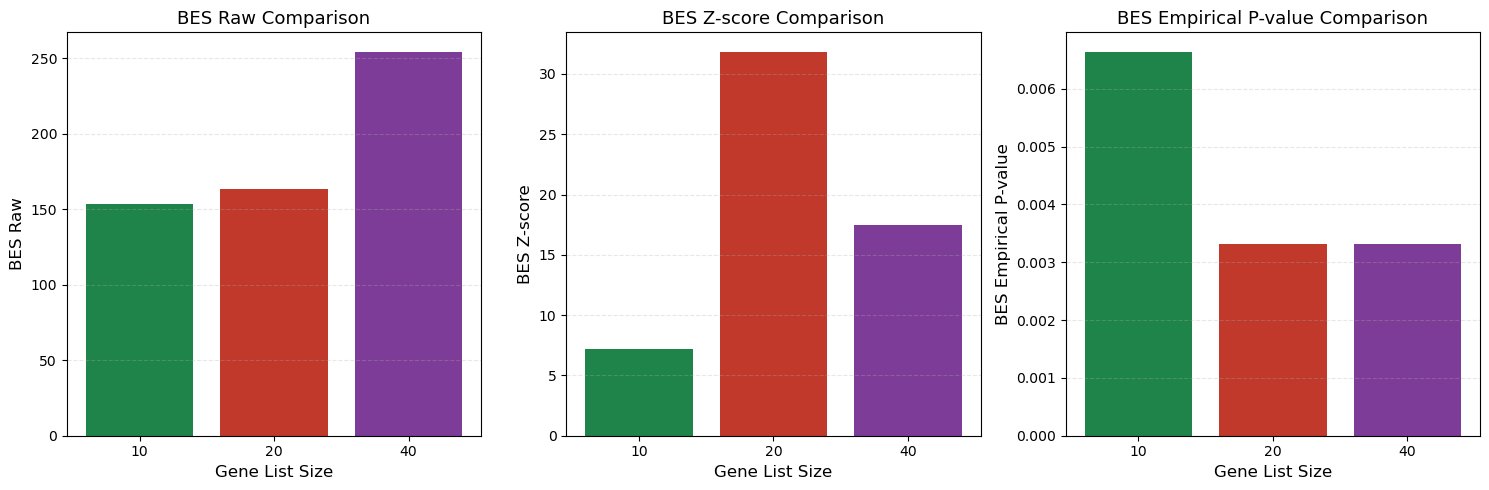

In [95]:
import matplotlib.pyplot as plt

x = [1, 2, 3]
x_labels = ["10", "20", "40"]
bar_colors = ["#1E8449", "#C0392B", "#7D3C98"]  # different color per bar

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# BES Raw
axes[0].bar(x, [bes_raw_10, bes_raw_20, bes_raw_40], color=bar_colors)
axes[0].set_xlabel("Gene List Size", fontsize=12)
axes[0].set_ylabel("BES Raw", fontsize=12)
axes[0].set_title("BES Raw Comparison", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

# BES Z-score
axes[1].bar(x, [bes_z_10, bes_z_20, bes_z_40], color=bar_colors)
axes[1].set_xlabel("Gene List Size", fontsize=12)
axes[1].set_ylabel("BES Z-score", fontsize=12)
axes[1].set_title("BES Z-score Comparison", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")

# BES Empirical P-value
axes[2].bar(x, [bes_p_emp_10, bes_p_emp_20, bes_p_emp_40], color=bar_colors)
axes[2].set_xlabel("Gene List Size", fontsize=12)
axes[2].set_ylabel("BES Empirical P-value", fontsize=12)
axes[2].set_title("BES Empirical P-value Comparison", fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(x_labels)
axes[2].grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()